In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'
    colab = False

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [100]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.v2 as tv2
import torchvision.transforms.v2.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu
import torchvision.ops as tvo
import torchvision

from torchinfo import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
COCO=False
VOC=True

In [101]:
# https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_e2e.html
if COCO:
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img_train = tds.CocoDetection(
        root=dataset_root + '/coco/train2017/',
        annFile=dataset_root + '/coco/annotations/instances_train2017.json',
        transforms=train_tfs_v2
    )

    img_train = tds.wrap_dataset_for_transforms_v2(img_train)

    img_val = tds.CocoDetection(
        root=dataset_root + '/coco/val2017/',
        annFile=dataset_root + '/coco/annotations/instances_val2017.json',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)
elif VOC:
    voc_class_names = ["background", "aeroplane", "bicycle", "bird", "boat", "bottle",
                       "bus", "car", "cat", "chair", "cow", "diningtable", "dog", "horse",
                       "motorbike", "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"]
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    img_train = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='train',
        transforms=train_tfs_v2
    )
    img_train = tds.wrap_dataset_for_transforms_v2(img_train)


    img_val = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='val',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)

Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets
Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets


In [102]:
def xywh_to_xyxy(boxes):
    boxes[..., 2] = boxes[..., 0] + boxes[..., 2]
    boxes[..., 3] = boxes[..., 1] + boxes[..., 3]
    return boxes

def xywh_to_cxywh(boxes):
    boxes[..., 0] = boxes[..., 0] + boxes[..., 2] // 2
    boxes[..., 1] = boxes[..., 1] + boxes[..., 3] // 2
    return boxes
    
class YoloConvertBoxes(nn.Module):
    def __init__(self, stride, canvas_size, num_classes):  
        super().__init__()
        self.stride = stride
        
        self.num_classes = num_classes
        
        self.w, self. h = canvas_size
        assert (self.w % stride == 0) and (self.h % stride == 0)
        
        self.box_loss = nn.L1Loss()
        self.cl_loss = nn.BCEWithLogitsLoss()
        
        w, h = canvas_size
        assert (w % stride == 0) and (h % stride == 0)
        
    # Convert boxes to be relative to the image cell
    # [cellx, celly, coffsetx, coffsety, width, height]
    def convert_xywh_to_cells(self, boxes):
        as_cxywh = xywh_to_cxywh(boxes.float())
        # print("CXY: ", as_cxywh)
        
        # nc = nearest_corners
        nc = torch.zeros_like(as_cxywh)
        nc[..., 0] = (as_cxywh[..., 0] // self.stride) * self.stride
        nc[..., 1] = (as_cxywh[..., 1] // self.stride) * self.stride
        cell_ix = (nc / self.stride)[..., :2].long()
        # print("Cell IX: ", cell_ix)
        # print("Nearest Corner: ", nc)
        
        # xoffset, yoffset, w, h
        offsets = (as_cxywh - nc)
        # print("Offsets: ", offsets)
        
        # Normalize the offset from nearest cell corner to the stride and
        # normalize the width and height to the canvas size. This places all
        # values between 0 and 1.
        offsets[..., 0] = offsets[..., 0] / self.stride
        offsets[..., 1] = offsets[..., 1] / self.stride
        offsets[..., 2] = offsets[..., 2] / self.w
        offsets[..., 3] = offsets[..., 3] / self.h
        
        return cell_ix, offsets
        
    
    # Boxes in [N, num_cells, 4]
    # * xywh ordering, x & y are the top left corner
    # * num_cells is (canvas_dim / stride)^2 for each stride.
    # Classes are onehot in [N, num_classes]
    def forward(self, tboxes, tclasses):
        cell_ixs, converted_tgt_box = self.convert_xywh_to_cells(tboxes)

        class_grid = torch.zeros(
            self.h // self.stride,
            self.w // self.stride,
            self.num_classes,
            dtype=torch.float32
        )
        
        box_grid = torch.zeros(
            self.h // self.stride,
            self.w // self.stride,
            4,
            dtype=torch.float32
        )

        for ix, cl, bb in zip(cell_ixs, tclasses, converted_tgt_box):
            (y, x) = ix
            class_grid[y, x, :] = cl
            box_grid[y, x, :] = bb
        
        return class_grid, box_grid
        

In [103]:
class VocDetectionWrapper():
    def __init__(self, voc, stride):
        self.voc = voc
        self.stride = stride
        self.canvas_size = (640, 640)
        self.num_classes = 20
        
        self.converter = YoloConvertBoxes(self.stride, self.canvas_size, self.num_classes)
    
    def __getitem__(self, ix):
        img, boxes = self.voc[ix]
    
        boxes['boxes'].data = boxes['boxes']
        boxes['labels'] = F.one_hot(boxes['labels'].to(torch.long) - 1, num_classes=self.num_classes)
        # Returns boxes in xywh format normalized to [0,1] according to box dimensions
        # Returns the classes as a one hot vector.
        # return img, boxes
        
        cgrid, bgrid = self.converter(boxes['boxes'], boxes['labels'])
        out = torch.cat((bgrid, cgrid), axis=-1)
        # return img, out.flatten(0, 1)
        return img, cgrid, bgrid
    
    def __len__(self):
        return len(self.voc)
    
    def plot(self, ix, thresh=0.1):
        img, cgrid, bgrid = self.__getitem__(ix)
        
        gy, gx, _ = cgrid.shape
        w0, h0 = self.canvas_size
        
        labels = []
        boxes_to_plot = []
        for iy in range(gy):
            for ix in range(gx):
                if torch.max(cgrid[iy, ix, :]) > thresh:

                    labels.append(voc_class_names[(torch.argmax(cgrid[iy, ix, :]).item() + 1)])
                    offsetx = bgrid[iy, ix, 0].item() * self.stride
                    offsety = bgrid[iy, ix, 1].item() * self.stride

                    
                    w = bgrid[iy, ix, 2].item() * w0
                    h = bgrid[iy, ix, 3].item() * h0

                    globalx = (iy * self.stride) + offsetx - w//2
                    globaly = (ix * self.stride) + offsety - h//2


                    # Now xyxy
                    boxes_to_plot.append(torch.tensor([globalx, globaly, globalx + w, globaly + h]))
        boxes_to_plot = torch.stack(boxes_to_plot)
        
        if img.dtype.is_floating_point and img.min() < 0:
            # Poor man's re-normalization for the colors to be OK-ish. This
            # is useful for images coming out of Normalize()
            img -= img.min()
            img /= img.max()

        img = tvf.to_dtype(img, torch.uint8, scale=True)
        drawn = tu.draw_bounding_boxes(
            img,
            boxes_to_plot,
            labels=labels, width=4,
            font="Ubuntu-M.ttf", font_size=32)
        plt.imshow(drawn.permute(1, 2, 0))
    
dset_train = VocDetectionWrapper(img_train, 40)
dset_val = VocDetectionWrapper(img_val, 40)

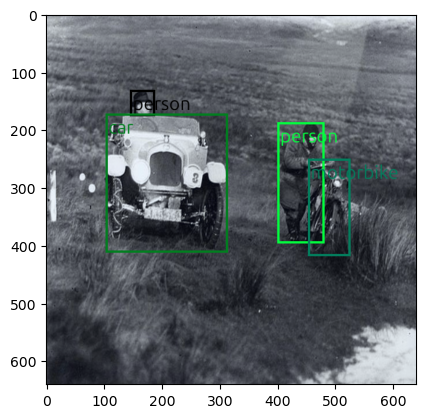

In [104]:
# dset_val[3]
dset_val.plot(49)

In [105]:
batchsize = 8

train_loader = tud.DataLoader(dset_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(dset_val, num_workers=cpu_num, batch_size=batchsize, shuffle=True)

In [107]:
# model = MyCnn(out_sz=10, ch=32).to(device).train()

# optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

class_lossfn = nn.BCEWithLogitsLoss()
bbox_lossfn = nn.L1Loss()
epochs = 50

# loss_plot = []
    # model.train()
for i, (images, cgrid, bgrid) in enumerate(train_loader):
    # optimizer.zero_grad()
    images = images.float()

    p_bgrid = torch.randn(8, 16*16, 4).requires_grad_()
    p_cgrid = torch.randn(8, 16*16, 20).requires_grad_()

    class_loss = class_lossfn(p_cgrid, cgrid.flatten(1,2))
    bbox_loss = bbox_lossfn(p_bgrid, bgrid.flatten(1,2))

    loss = class_loss + bbox_loss
    loss.backward()
    break

    

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn